In [4]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Ayush\Downloads\archive\apple_products_pricing_2020_2026.csv")

print(df.head())

         Date  Platform Product_Category                   Model_Name  \
0  2020-09-19  Flipkart            Watch  Apple Watch Series 6 (44mm)   
1  2020-09-20  Flipkart            Watch  Apple Watch Series 6 (44mm)   
2  2020-09-23    Amazon            Watch  Apple Watch Series 6 (44mm)   
3  2020-09-23    Amazon            Watch  Apple Watch Series 6 (44mm)   
4  2020-09-24    Amazon            Watch  Apple Watch Series 6 (44mm)   

  Condition  Launch_Price_USD  Launch_Price_INR  Current_Price_USD  \
0       New               429             42042             435.81   
1       New               429             42042             436.49   
2       New               429             42042             422.73   
3       New               429             42042             425.00   
4       New               429             42042             436.22   

   Current_Price_INR  Discount_Pct Sale_Event  Stock_Status  Rating  \
0           43322.41          -1.6        NaN      In Stock     4.7  

In [6]:
df.isnull().sum()

Date                     0
Platform                 0
Product_Category         0
Model_Name               0
Condition                0
Launch_Price_USD         0
Launch_Price_INR         0
Current_Price_USD        0
Current_Price_INR        0
Discount_Pct             0
Sale_Event           73351
Stock_Status             0
Rating                   0
Reviews_Count            0
dtype: int64

In [12]:
df["Sale_Event"] = df["Sale_Event"].fillna("Regular Days")

In [14]:
df.duplicated().sum()

np.int64(0)

In [23]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

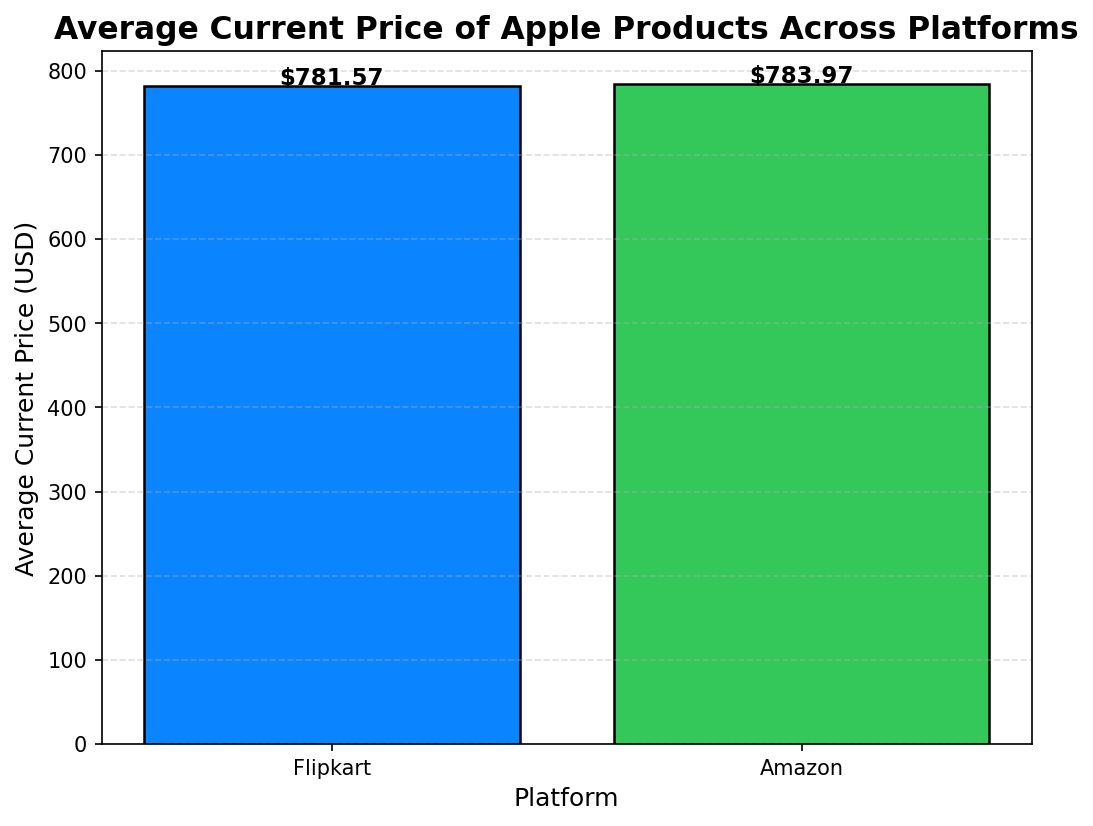

In [24]:
import matplotlib.pyplot as plt
import numpy as np

platform_price = df.groupby("Platform")["Current_Price_USD"].mean().sort_values()

colors = ["#0A84FF", "#34C759"]   # Apple Blue & Green

plt.figure(figsize=(8,6), dpi=150)

bars = plt.bar(platform_price.index,
               platform_price.values,
               color=colors,
               edgecolor="black",
               linewidth=1.2)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+2,
             f"${bar.get_height():.2f}",
             ha="center",
             fontsize=11,
             fontweight="bold")

plt.title("Average Current Price of Apple Products Across Platforms",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Platform", fontsize=12)
plt.ylabel("Average Current Price (USD)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=.4)

plt.show()

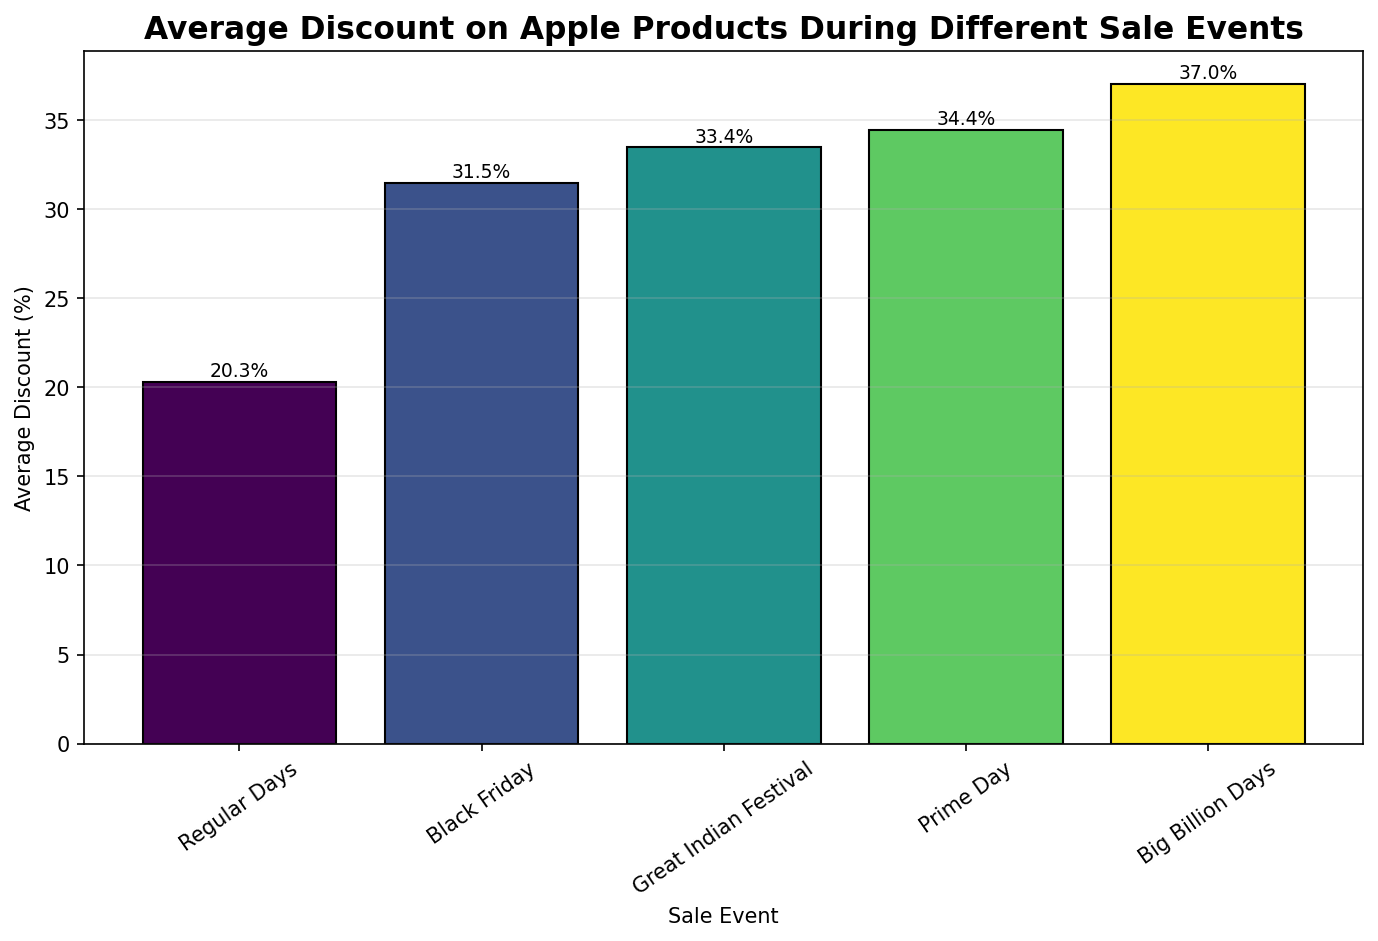

In [25]:
sale_discount = df.groupby("Sale_Event")["Discount_Pct"].mean().sort_values()

plt.figure(figsize=(11,6), dpi=150)

bars = plt.bar(
    sale_discount.index,
    sale_discount.values,
    color=plt.cm.viridis(np.linspace(0,1,len(sale_discount))),
    edgecolor="black"
)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.3,
             f"{bar.get_height():.1f}%",
             ha="center",
             fontsize=9)

plt.xticks(rotation=35)

plt.title("Average Discount on Apple Products During Different Sale Events",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Sale Event")
plt.ylabel("Average Discount (%)")

plt.grid(axis="y", alpha=.3)

plt.show()

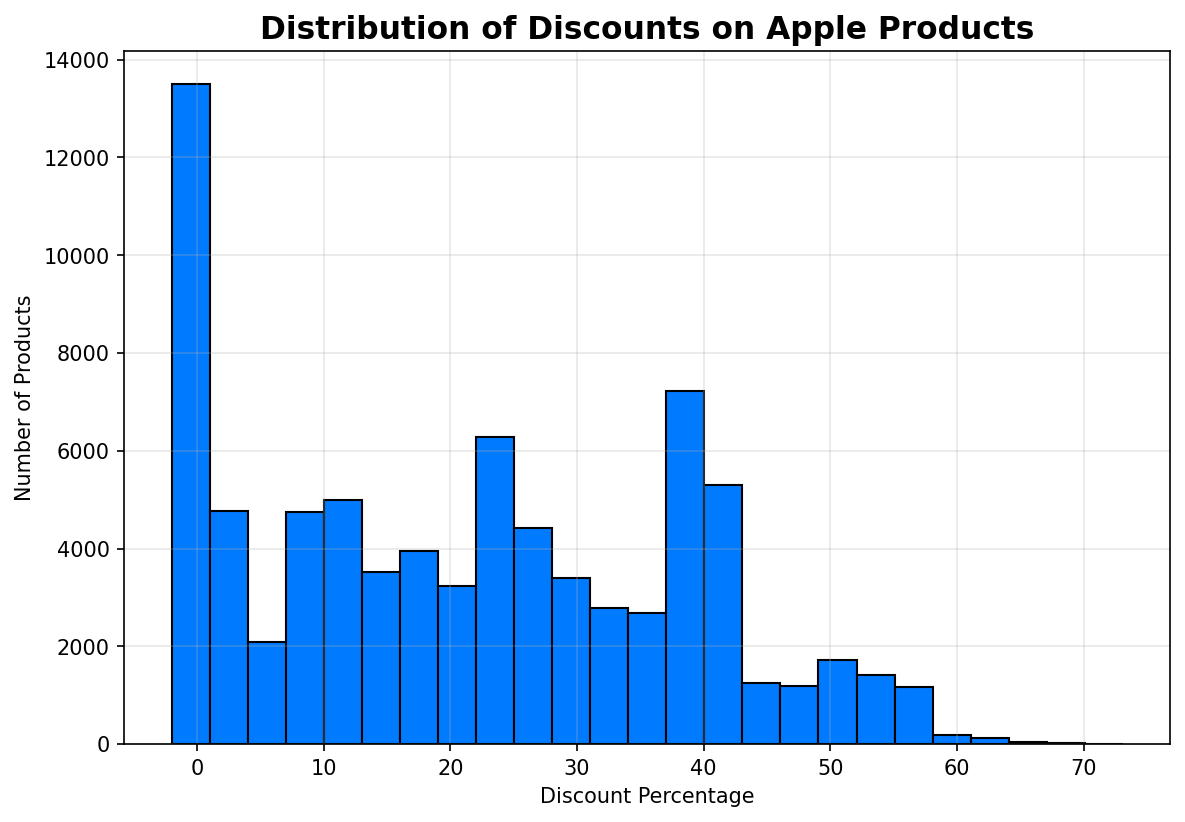

In [26]:
plt.figure(figsize=(9,6), dpi=150)

plt.hist(
    df["Discount_Pct"],
    bins=25,
    color="#007AFF",
    edgecolor="black"
)

plt.title("Distribution of Discounts on Apple Products",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Discount Percentage")
plt.ylabel("Number of Products")

plt.grid(alpha=.3)

plt.show()

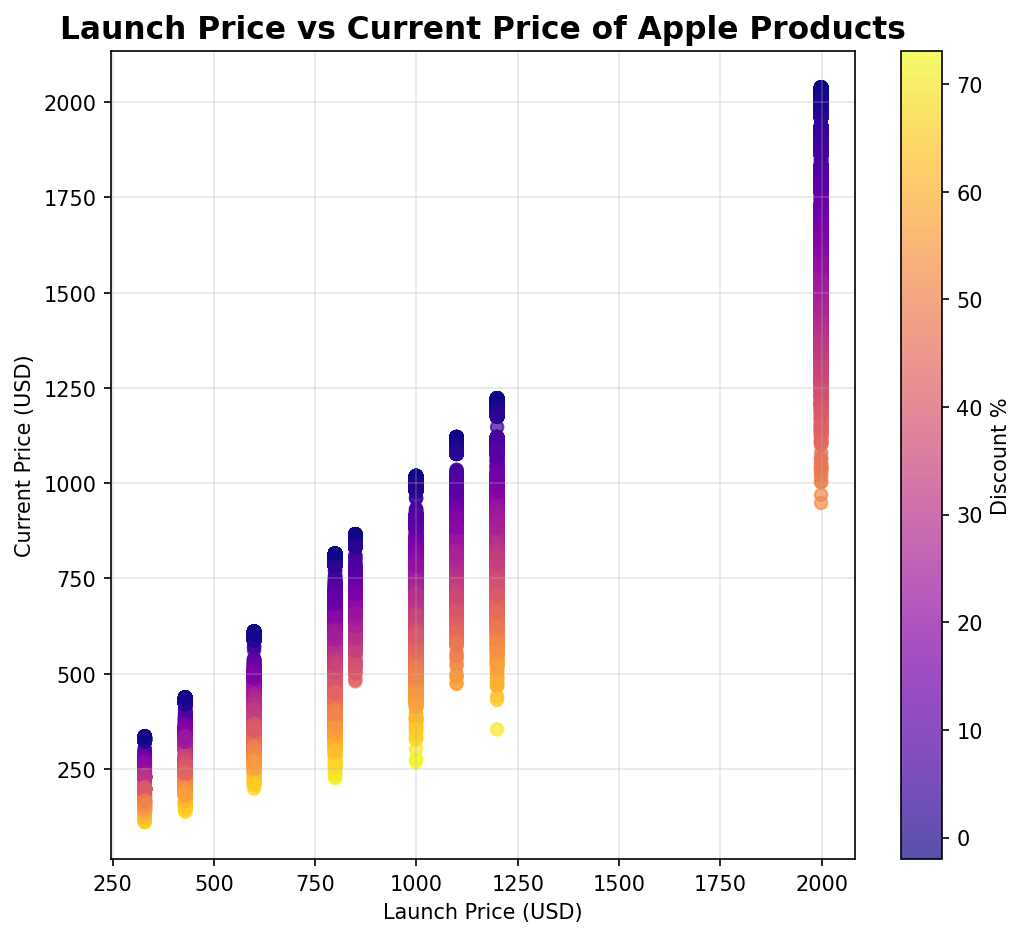

In [27]:
plt.figure(figsize=(8,7), dpi=150)

scatter = plt.scatter(
    df["Launch_Price_USD"],
    df["Current_Price_USD"],
    c=df["Discount_Pct"],
    cmap="plasma",
    alpha=.7
)

plt.colorbar(scatter,label="Discount %")

plt.title("Launch Price vs Current Price of Apple Products",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Launch Price (USD)")
plt.ylabel("Current Price (USD)")

plt.grid(alpha=.3)

plt.show()

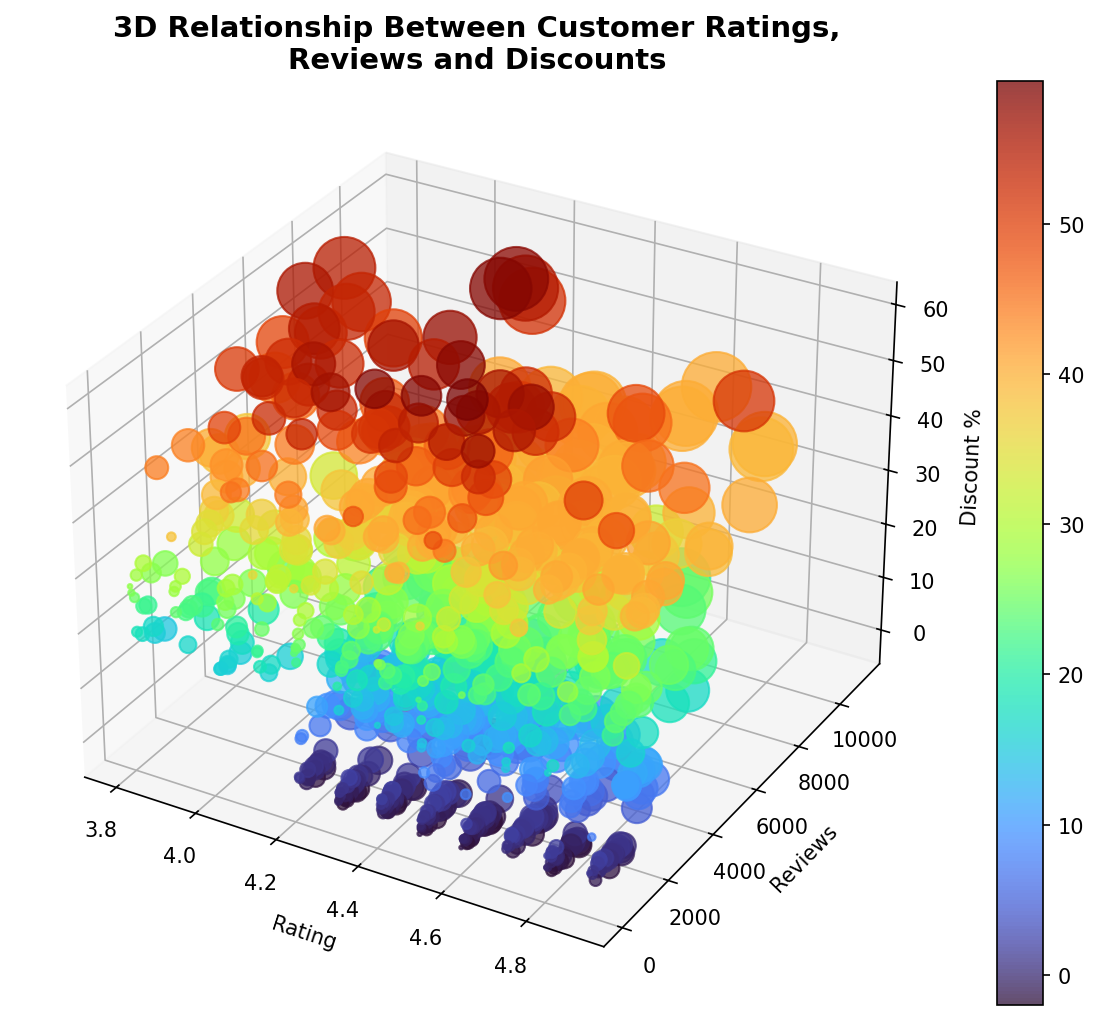

In [28]:
from mpl_toolkits.mplot3d import Axes3D

sample = df.sample(1000, random_state=42)

fig = plt.figure(figsize=(10,8), dpi=150)

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    sample["Rating"],
    sample["Reviews_Count"],
    sample["Discount_Pct"],
    c=sample["Discount_Pct"],
    cmap="turbo",
    s=sample["Reviews_Count"]/10,
    alpha=.75
)

ax.set_title(
    "3D Relationship Between Customer Ratings,\nReviews and Discounts",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Rating")
ax.set_ylabel("Reviews")
ax.set_zlabel("Discount %")

plt.colorbar(scatter)

plt.show()

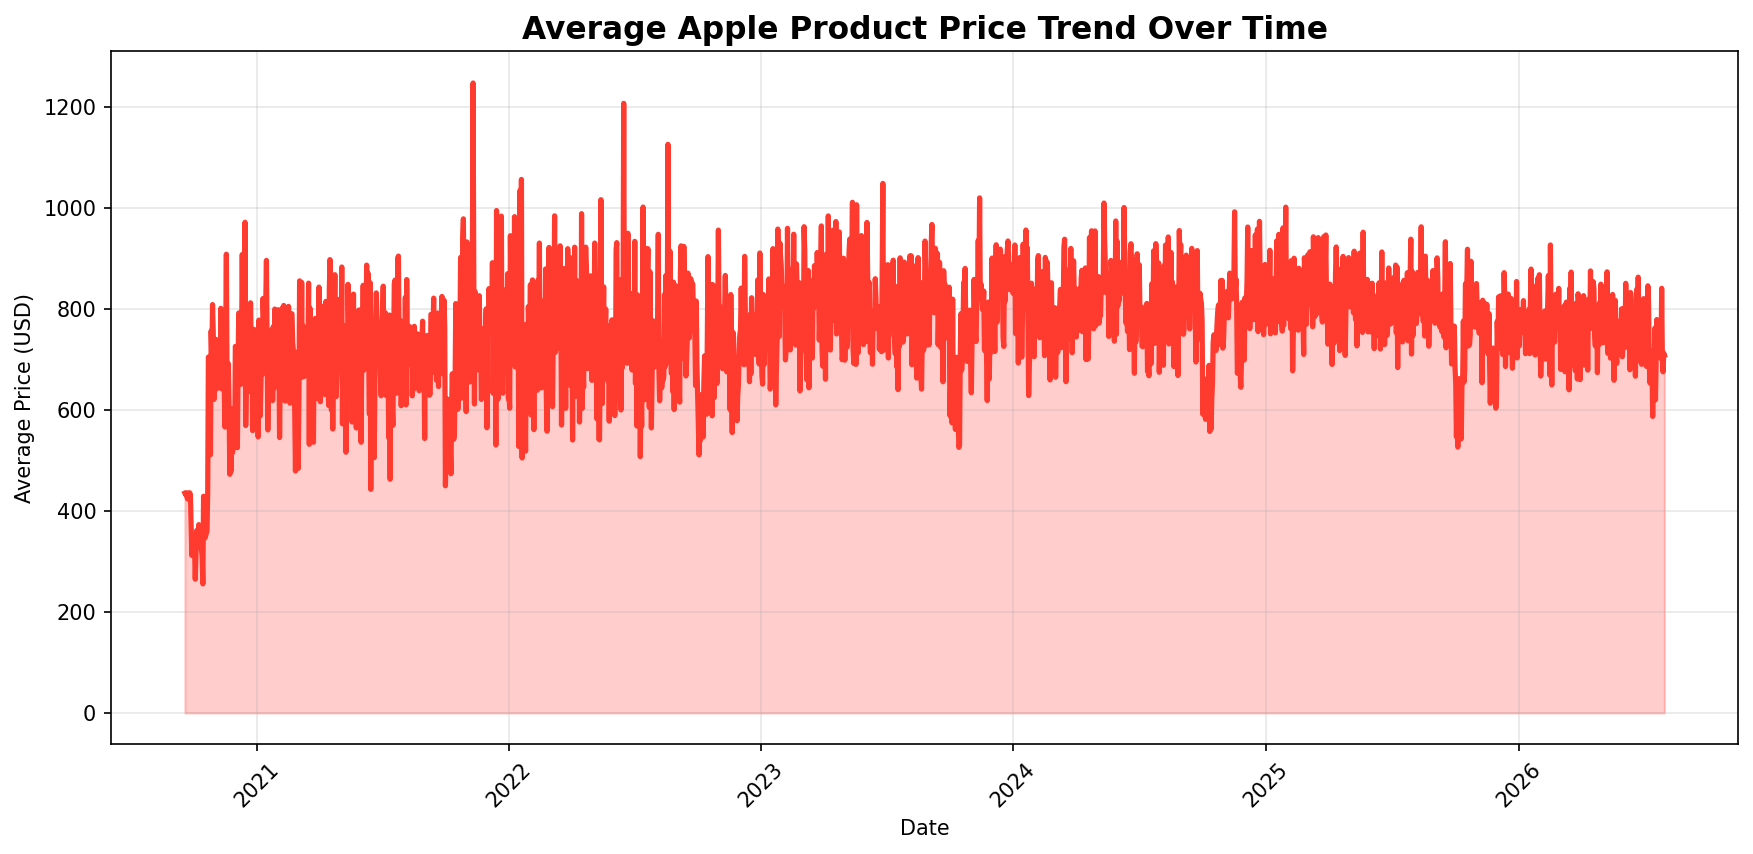

In [29]:
price = df.groupby("Date")["Current_Price_USD"].mean()

plt.figure(figsize=(14,6), dpi=150)

plt.plot(
    price.index,
    price.values,
    color="#FF3B30",
    linewidth=2.5
)

plt.fill_between(
    price.index,
    price.values,
    alpha=.25,
    color="#FF3B30"
)

plt.title(
    "Average Apple Product Price Trend Over Time",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Average Price (USD)")

plt.grid(alpha=.3)

plt.xticks(rotation=45)

plt.show()

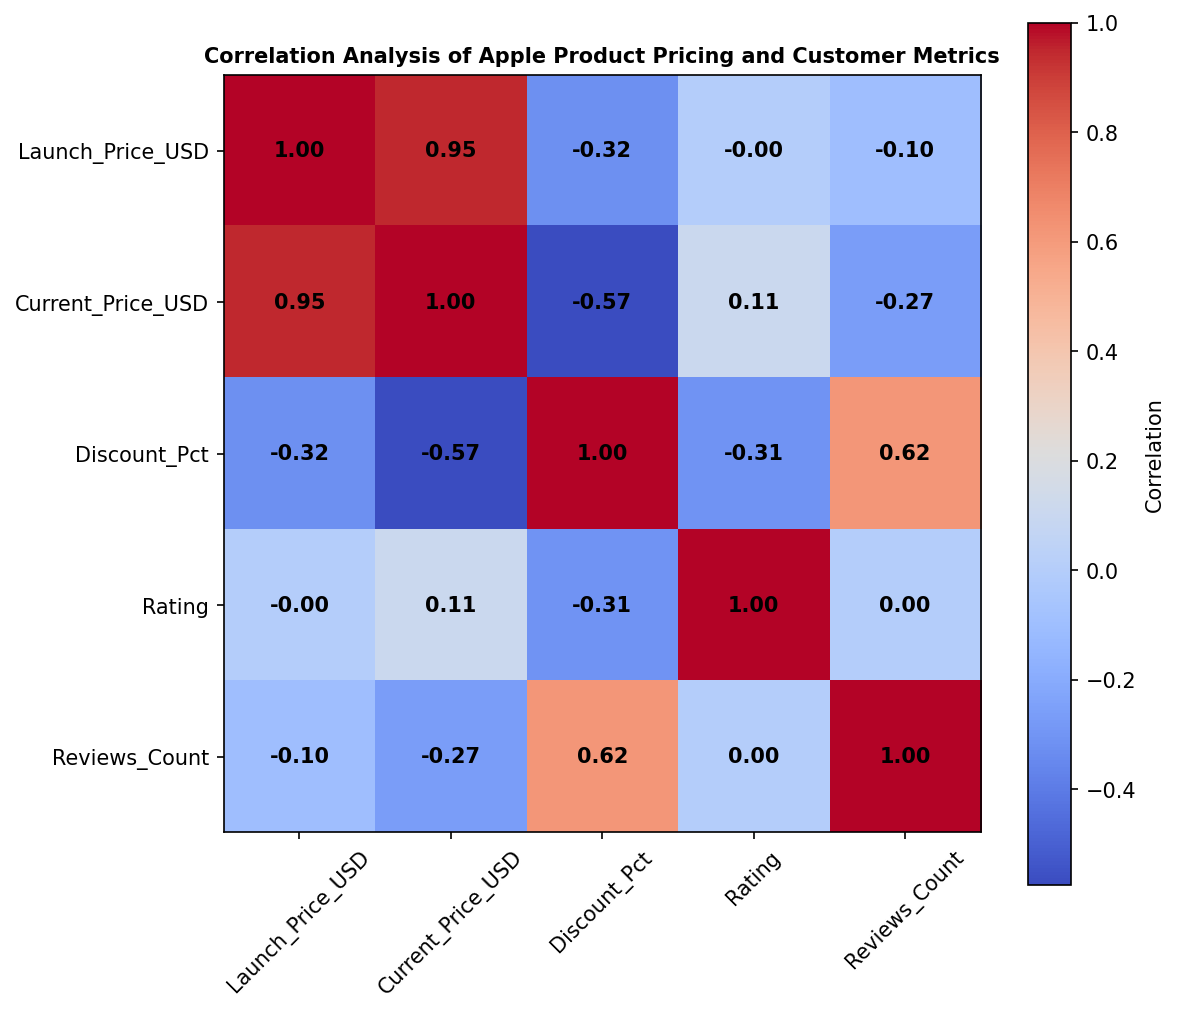

In [35]:
corr = df[
    [
        "Launch_Price_USD",
        "Current_Price_USD",
        "Discount_Pct",
        "Rating",
        "Reviews_Count"
    ]
].corr()

plt.figure(figsize=(8,7), dpi=150)

plt.imshow(corr,
           cmap="coolwarm",
           interpolation="nearest")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    fontsize=10
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns,
    fontsize=10
)

# Correlation values inside boxes
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="black"
        )

plt.title(
    "Correlation Analysis of Apple Product Pricing and Customer Metrics",
    fontsize=10,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

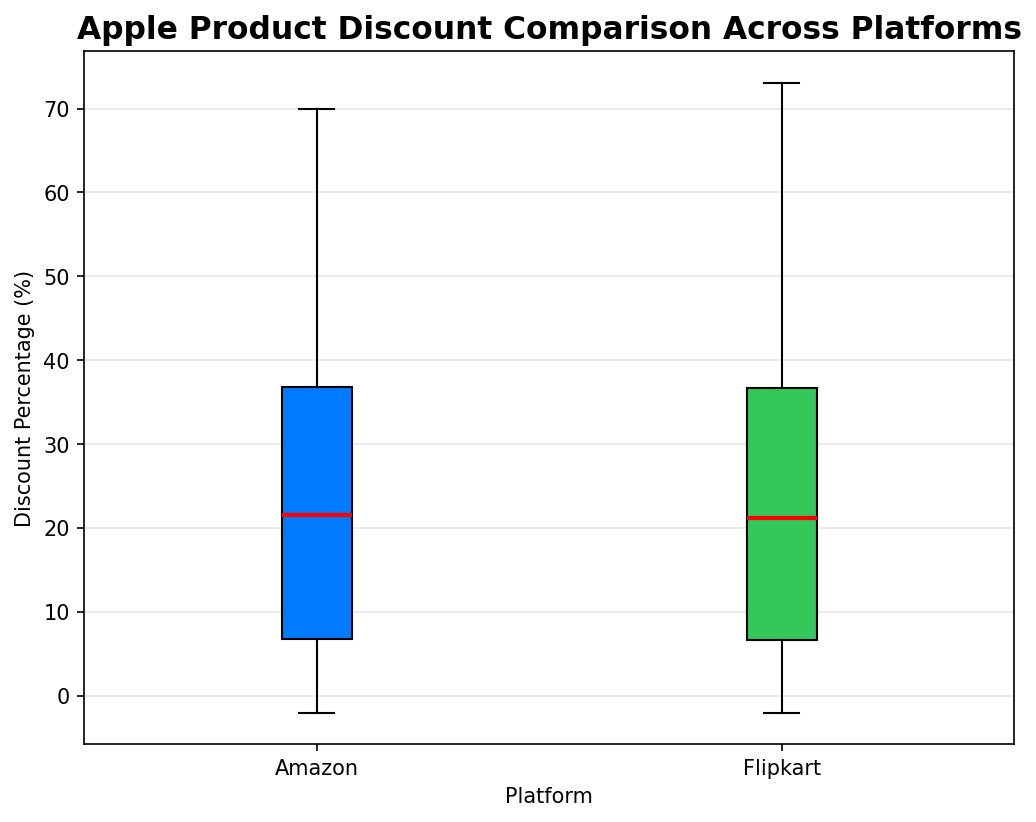

In [37]:
amazon = df[df["Platform"] == "Amazon"]["Discount_Pct"]
flipkart = df[df["Platform"] == "Flipkart"]["Discount_Pct"]

plt.figure(figsize=(8,6), dpi=150)

box = plt.boxplot(
    [amazon, flipkart],
    tick_labels=["Amazon", "Flipkart"],
    patch_artist=True
)

colors = ["#007AFF", "#34C759"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

for median in box["medians"]:
    median.set(color="red", linewidth=2)

plt.title(
    "Apple Product Discount Comparison Across Platforms",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Platform")
plt.ylabel("Discount Percentage (%)")

plt.grid(axis="y", alpha=0.3)

plt.show()